# Latent factor correlation analysis

This notebook compares latent dimensions from AE, EFA, PCA, and KPCA using Pearson correlation matrices. The analysis is treated as **descriptive factor-alignment/similarity analysis**. Because the sample size is large, interpretation focuses on Pearson *r* and absolute *r*, not p-values or FDR-corrected significance. Heatmaps therefore show correlation coefficients only, with no significance stars.

In [2]:
# ============================================================
# Pearson correlation comparison among AE, EFA, PCA, and KPCA latent factors
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from pathlib import Path
from validators import build_model_scores


# Note:
# This notebook treats Pearson correlations as descriptive similarity/alignment measures.
# The key quantity for interpretation is Pearson r, especially |r| and the matching pattern.


def _natural_factor_sort(cols):
    """Sort columns with suffix numbers, e.g., factor_1, factor_2, ..."""
    def _key(x):
        try:
            return int(str(x).split("_")[-1])
        except Exception:
            return 10**9
    return sorted(cols, key=_key)


def load_latent_scores(
    qns: pd.DataFrame,
    file_path: Path,
    prefix: str,
    id_col: str = "src_subject_id",
    k: int = None,
):
    """
    Load saved latent factor scores and attach src_subject_id using build_model_scores().

    The saved file is expected to contain only latent dimensions, or may contain an
    accidental index column such as Unnamed: 0, which will be removed.

    Output columns:
        src_subject_id + {prefix}_1 ... {prefix}_K
    """
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find latent factor file: {file_path}")

    latent = pd.read_csv(file_path, encoding="utf-8")
    latent = latent.loc[:, ~latent.columns.astype(str).str.contains("^Unnamed")]

    if k is not None:
        if latent.shape[1] < k:
            raise ValueError(
                f"{file_path.name} has only {latent.shape[1]} columns, but K={k} was requested."
            )
        latent = latent.iloc[:, :k]

    scores = build_model_scores(
        qns=qns,
        latent_factors=latent.to_numpy(),
        id_colname=id_col,
    )

    rename_map = {
        f"factor_{i}": f"{prefix}_{i}"
        for i in range(1, latent.shape[1] + 1)
    }
    scores = scores.rename(columns=rename_map)
    return scores


def find_first_existing_path(paths):
    """Return the first existing path from a list of candidates."""
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of the candidate files exist:\n" + "\n".join(str(p) for p in paths)
    )


def compare_two_factor_sets_pearson(
    scores_a: pd.DataFrame,
    scores_b: pd.DataFrame,
    id_col: str = "src_subject_id",
    prefix_a: str = "ae_",
    prefix_b: str = "efa_",
    name_a: str = "AE",
    name_b: str = "EFA",
    save_dir=None,
    label: str = "factor_set_comparison",
):
    """
    Descriptive Pearson correlation comparison between two latent factor score sets.

    This function does not perform FDR correction and does not use significance stars.
    It returns p-values only as optional diagnostics; interpretation should focus on
    Pearson r and absolute r.

    Returns
    -------
    dict with:
        merged
        long_results
        r_matrix
        p_matrix
    """
    a = scores_a.copy()
    b = scores_b.copy()

    a[id_col] = a[id_col].astype(str)
    b[id_col] = b[id_col].astype(str)

    cols_a = _natural_factor_sort([c for c in a.columns if c.startswith(prefix_a)])
    cols_b = _natural_factor_sort([c for c in b.columns if c.startswith(prefix_b)])

    if not cols_a:
        raise ValueError(f"No {name_a} factor columns found with prefix '{prefix_a}'.")
    if not cols_b:
        raise ValueError(f"No {name_b} factor columns found with prefix '{prefix_b}'.")

    merged = a[[id_col] + cols_a].merge(
        b[[id_col] + cols_b],
        on=id_col,
        how="inner",
    )

    rows = []
    for col_a in cols_a:
        for col_b in cols_b:
            d = merged[[col_a, col_b]].dropna()

            if d.shape[0] < 30:
                r, p = np.nan, np.nan
            else:
                r, p = pearsonr(
                    d[col_a].astype(float),
                    d[col_b].astype(float),
                )

            rows.append({
                f"{name_a}_factor": col_a,
                f"{name_b}_factor": col_b,
                "n": d.shape[0],
                "pearson_r": r,
                "p_value_unadjusted": p,
                "abs_r": abs(r) if pd.notna(r) else np.nan,
            })

    long_results = pd.DataFrame(rows)

    r_matrix = long_results.pivot(
        index=f"{name_a}_factor",
        columns=f"{name_b}_factor",
        values="pearson_r",
    )
    p_matrix = long_results.pivot(
        index=f"{name_a}_factor",
        columns=f"{name_b}_factor",
        values="p_value_unadjusted",
    )

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        long_results.to_csv(
            save_dir / f"{label}_pearson_long_results.csv",
            index=False,
            encoding="utf-8-sig",
        )
        r_matrix.to_csv(
            save_dir / f"{label}_pearson_r_matrix.csv",
            encoding="utf-8-sig",
        )
        p_matrix.to_csv(
            save_dir / f"{label}_pearson_unadjusted_p_matrix.csv",
            encoding="utf-8-sig",
        )

    return {
        "merged": merged,
        "long_results": long_results,
        "r_matrix": r_matrix,
        "p_matrix": p_matrix,
    }


def plot_factor_correlation_heatmap(
    corr_result,
    title,
    save_path=None,
    figsize=(6, 5),
):
    """Plot heatmap for one descriptive Pearson correlation comparison."""
    r_matrix = corr_result["r_matrix"]

    fig, ax = plt.subplots(figsize=figsize)

    vmax = np.nanmax(np.abs(r_matrix.values))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1

    im = ax.imshow(
        r_matrix.values,
        aspect="auto",
        vmin=-vmax,
        vmax=vmax,
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Pearson r")

    ax.set_xticks(np.arange(r_matrix.shape[1]))
    ax.set_xticklabels(r_matrix.columns, rotation=45, ha="right")

    ax.set_yticks(np.arange(r_matrix.shape[0]))
    ax.set_yticklabels(r_matrix.index)

    for i in range(r_matrix.shape[0]):
        for j in range(r_matrix.shape[1]):
            r_val = r_matrix.iloc[i, j]
            if np.isfinite(r_val):
                ax.text(
                    j,
                    i,
                    f"{r_val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                )

    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    if save_path is not None:
        print("Saved to:", save_path)


def get_best_matches(corr_result, name_a, name_b):
    """Best-matching factor in B for each factor in A by absolute Pearson r."""
    a_col = f"{name_a}_factor"
    b_col = f"{name_b}_factor"
    best = (
        corr_result["long_results"]
        .sort_values("abs_r", ascending=False)
        .groupby(a_col, as_index=False)
        .first()
        .sort_values(a_col)
    )
    return best[[a_col, b_col, "n", "pearson_r", "abs_r", "p_value_unadjusted"]]


In [ ]:
# ============================================================
# Load AE, EFA, PCA, and KPCA latent factors for K=5
# ============================================================

code_dir = Path.cwd()
data_path = code_dir.parent / "data"
data_file = data_path / "cbcl_data_remove_low_frequency.csv"

results_dir = code_dir / "temp" / "ae_efa_pca_kpca_factor_correlations"
results_dir.mkdir(parents=True, exist_ok=True)

print("Results will be saved to:", results_dir)

if not data_file.exists():
    raise FileNotFoundError(f"Could not find {data_file}")

qns = pd.read_csv(data_file, encoding="utf-8")

encoding_dim = K = 5

# -----------------------------
# Candidate file paths
# -----------------------------
ae_path = find_first_existing_path([
    code_dir / "temp" / f"latent_factors_ae_dim{K}.csv",
])

efa_path = find_first_existing_path([
    code_dir / "temp" / f"latent_factors_efa_dim{K}.csv",
])

pca_path = find_first_existing_path([
    code_dir / "temp" / f"latent_factors_pca_dim{K}.csv",
])

kpca_path = find_first_existing_path([
    code_dir / "temp" / f"latent_factors_kpca_dim{K}.csv",
])

print("AE file:", ae_path)
print("EFA file:", efa_path)
print("PCA file:", pca_path)
print("KPCA file:", kpca_path)

# -----------------------------
# Load scores and assign unique prefixes
# -----------------------------
ae_scores_k = load_latent_scores(qns, ae_path, prefix="ae", k=K)
efa_scores_k = load_latent_scores(qns, efa_path, prefix="efa", k=K)
pca_scores_k = load_latent_scores(qns, pca_path, prefix="pca", k=K)
kpca_scores_k = load_latent_scores(qns, kpca_path, prefix="kpca", k=K)

print("AE columns:", ae_scores_k.columns.tolist())
print("EFA columns:", efa_scores_k.columns.tolist())
print("PCA columns:", pca_scores_k.columns.tolist())
print("KPCA columns:", kpca_scores_k.columns.tolist())


Results will be saved to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive
AE file: g:\ABCD\script\trail\notebooks\temp\latent_factors_ae_dim5.csv
EFA file: g:\ABCD\script\trail\notebooks\temp\latent_factors_efa_dim5.csv
PCA file: g:\ABCD\script\trail\notebooks\temp\latent_factors_pca_dim5.csv
KPCA file: g:\ABCD\script\trail\notebooks\temp\latent_factors_kpca_dim5.csv
AE columns: ['src_subject_id', 'ae_1', 'ae_2', 'ae_3', 'ae_4', 'ae_5']
EFA columns: ['src_subject_id', 'efa_1', 'efa_2', 'efa_3', 'efa_4', 'efa_5']
PCA columns: ['src_subject_id', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5']
KPCA columns: ['src_subject_id', 'kpca_1', 'kpca_2', 'kpca_3', 'kpca_4', 'kpca_5']


In [3]:
# ============================================================
# Pearson comparisons among AE, EFA, PCA, and KPCA
# ============================================================

factor_sets = {
    "AE": {
        "scores": ae_scores_k,
        "prefix": "ae_",
    },
    "EFA": {
        "scores": efa_scores_k,
        "prefix": "efa_",
    },
    "PCA": {
        "scores": pca_scores_k,
        "prefix": "pca_",
    },
    "KPCA": {
        "scores": kpca_scores_k,
        "prefix": "kpca_",
    },
}

comparison_pairs = [
    ("AE", "EFA"),
    ("AE", "PCA"),
    ("AE", "KPCA"),
    ("EFA", "PCA"),
    ("EFA", "KPCA"),
    ("PCA", "KPCA"),
]

corr_results = {}
all_long_results = []

for name_a, name_b in comparison_pairs:
    print(f"\nRunning Pearson comparison: {name_a} vs {name_b}")

    out = compare_two_factor_sets_pearson(
        scores_a=factor_sets[name_a]["scores"],
        scores_b=factor_sets[name_b]["scores"],
        id_col="src_subject_id",
        prefix_a=factor_sets[name_a]["prefix"],
        prefix_b=factor_sets[name_b]["prefix"],
        name_a=name_a,
        name_b=name_b,
        save_dir=results_dir,
        label=f"{name_a}_dim{K}_vs_{name_b}_dim{K}",
    )

    corr_results[(name_a, name_b)] = out

    long_tmp = out["long_results"].copy()
    long_tmp.insert(0, "comparison", f"{name_a}_vs_{name_b}")
    all_long_results.append(long_tmp)

    display(out["r_matrix"])
    display(out["long_results"].sort_values("abs_r", ascending=False).head(10))

all_comparisons_long = pd.concat(all_long_results, axis=0, ignore_index=True)
all_comparisons_path = results_dir / f"all_pairwise_AE_EFA_PCA_KPCA_dim{K}_pearson_long_results.csv"
all_comparisons_long.to_csv(all_comparisons_path, index=False, encoding="utf-8-sig")

print("Saved combined long results to:", all_comparisons_path)



Running Pearson comparison: AE vs EFA


EFA_factor,efa_1,efa_2,efa_3,efa_4,efa_5
AE_factor,,,,,
ae_1,-0.650922,-0.114643,-0.108769,0.005114,-0.031109
ae_2,0.198404,0.603486,0.141149,0.447582,0.134741
ae_3,0.527875,0.427203,0.806594,0.294413,0.295765
ae_4,0.233965,-0.032421,0.110459,0.368424,0.172582
ae_5,-0.013008,0.428374,0.212205,-0.106823,0.658203


,AE_factor,EFA_factor,n,pearson_r,p_value_unadjusted,abs_r
12,ae_3,efa_3,9799,0.806594,0.000000e+00,0.806594
24,ae_5,efa_5,9799,0.658203,0.000000e+00,0.658203
0,ae_1,efa_1,9799,-0.650922,0.000000e+00,0.650922
6,ae_2,efa_2,9799,0.603486,0.000000e+00,0.603486
10,ae_3,efa_1,9799,0.527875,0.000000e+00,0.527875
8,ae_2,efa_4,9799,0.447582,0.000000e+00,0.447582
21,ae_5,efa_2,9799,0.428374,0.000000e+00,0.428374
11,ae_3,efa_2,9799,0.427203,0.000000e+00,0.427203
18,ae_4,efa_4,9799,0.368424,1.005723e-312,0.368424
14,ae_3,efa_5,9799,0.295765,4.896792e-197,0.295765



Running Pearson comparison: AE vs PCA


PCA_factor,pca_1,pca_2,pca_3,pca_4,pca_5
AE_factor,,,,,
ae_1,-0.332134,-0.520881,-0.198238,0.353534,0.072704
ae_2,0.423869,-0.281404,0.479604,0.147565,-0.191731
ae_3,0.690986,0.132300,-0.382532,0.150341,-0.165470
ae_4,0.199099,0.188671,0.034562,0.202039,0.410116
ae_5,0.270010,-0.530900,-0.210511,-0.402742,0.183239


...

,EFA_factor,KPCA_factor,n,pearson_r,p_value_unadjusted,abs_r
10,efa_3,kpca_1,9799,0.778186,0.000000e+00,0.778186
5,efa_2,kpca_1,9799,0.740549,0.000000e+00,0.740549
0,efa_1,kpca_1,9799,0.672815,0.000000e+00,0.672815
16,efa_4,kpca_2,9799,-0.619321,0.000000e+00,0.619321
20,efa_5,kpca_1,9799,0.610451,0.000000e+00,0.610451
23,efa_5,kpca_4,9799,0.507091,0.000000e+00,0.507091
2,efa_1,kpca_3,9799,-0.435416,0.000000e+00,0.435416
15,efa_4,kpca_1,9799,0.397992,0.000000e+00,0.397992
14,efa_3,kpca_5,9799,0.366457,3.629691e-309,0.366457
22,efa_5,kpca_3,9799,0.347285,8.830662e-276,0.347285



Running Pearson comparison: PCA vs KPCA


KPCA_factor,kpca_1,kpca_2,kpca_3,kpca_4,kpca_5
PCA_factor,,,,,
pca_1,0.905958,-0.130351,-0.059115,-0.035286,-0.056463
pca_2,-0.060110,0.040471,-0.745547,0.065432,-0.082922
pca_3,-0.132356,-0.342640,0.116763,-0.167958,-0.622861
pca_4,-0.073697,-0.418119,-0.108029,-0.505762,0.406248
pca_5,-0.014322,-0.420333,0.087108,0.623177,0.155608


,PCA_factor,KPCA_factor,n,pearson_r,p_value_unadjusted,abs_r
0,pca_1,kpca_1,9799,0.905958,0.000000e+00,0.905958
7,pca_2,kpca_3,9799,-0.745547,0.000000e+00,0.745547
23,pca_5,kpca_4,9799,0.623177,0.000000e+00,0.623177
14,pca_3,kpca_5,9799,-0.622861,0.000000e+00,0.622861
18,pca_4,kpca_4,9799,-0.505762,0.000000e+00,0.505762
21,pca_5,kpca_2,9799,-0.420333,0.000000e+00,0.420333
16,pca_4,kpca_2,9799,-0.418119,0.000000e+00,0.418119
19,pca_4,kpca_5,9799,0.406248,0.000000e+00,0.406248
11,pca_3,kpca_2,9799,-0.342640,4.911304e-268,0.342640
13,pca_3,kpca_4,9799,-0.167958,6.364214e-63,0.167958


Saved combined long results to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive\all_pairwise_AE_EFA_PCA_KPCA_dim5_pearson_long_results.csv


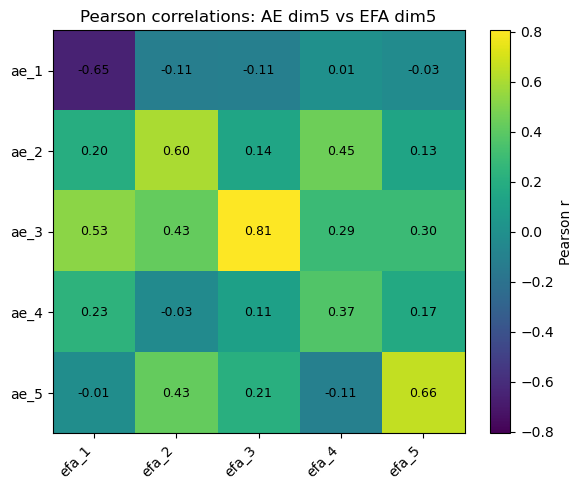

Saved to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive\AE_dim5_vs_EFA_dim5_pearson_heatmap.png


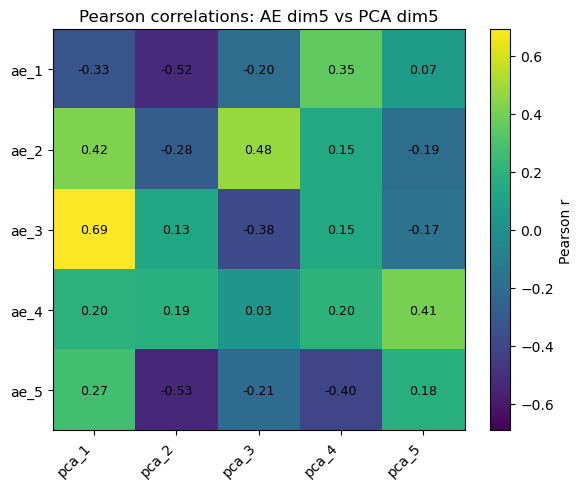

Saved to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive\AE_dim5_vs_PCA_dim5_pearson_heatmap.png


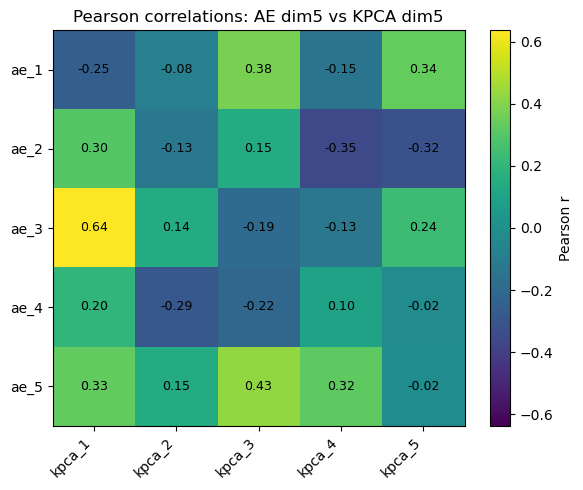

Saved to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive\AE_dim5_vs_KPCA_dim5_pearson_heatmap.png


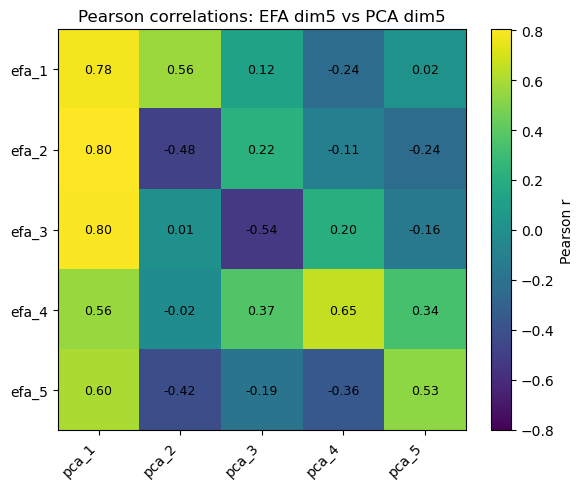

Saved to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive\EFA_dim5_vs_PCA_dim5_pearson_heatmap.png


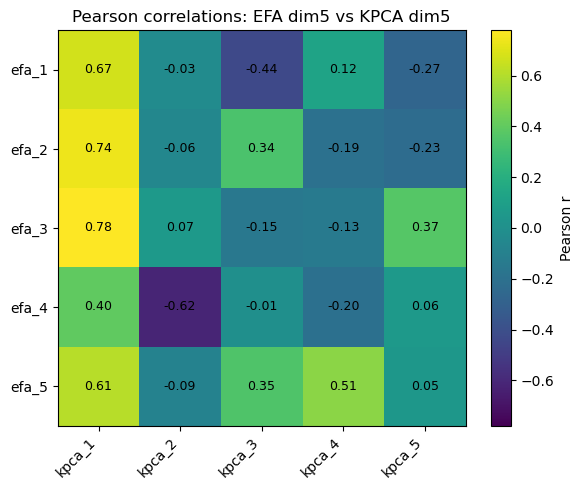

Saved to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive\EFA_dim5_vs_KPCA_dim5_pearson_heatmap.png


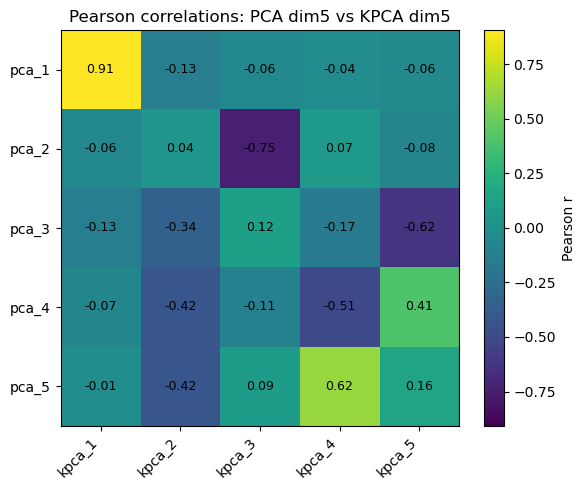

Saved to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive\PCA_dim5_vs_KPCA_dim5_pearson_heatmap.png


In [4]:
# ============================================================
# Plot all Pearson correlation heatmaps
# ============================================================

for (name_a, name_b), out in corr_results.items():
    plot_factor_correlation_heatmap(
        out,
        title=f"Pearson correlations: {name_a} dim{K} vs {name_b} dim{K}",
        save_path=results_dir / f"{name_a}_dim{K}_vs_{name_b}_dim{K}_pearson_heatmap.png",
    )


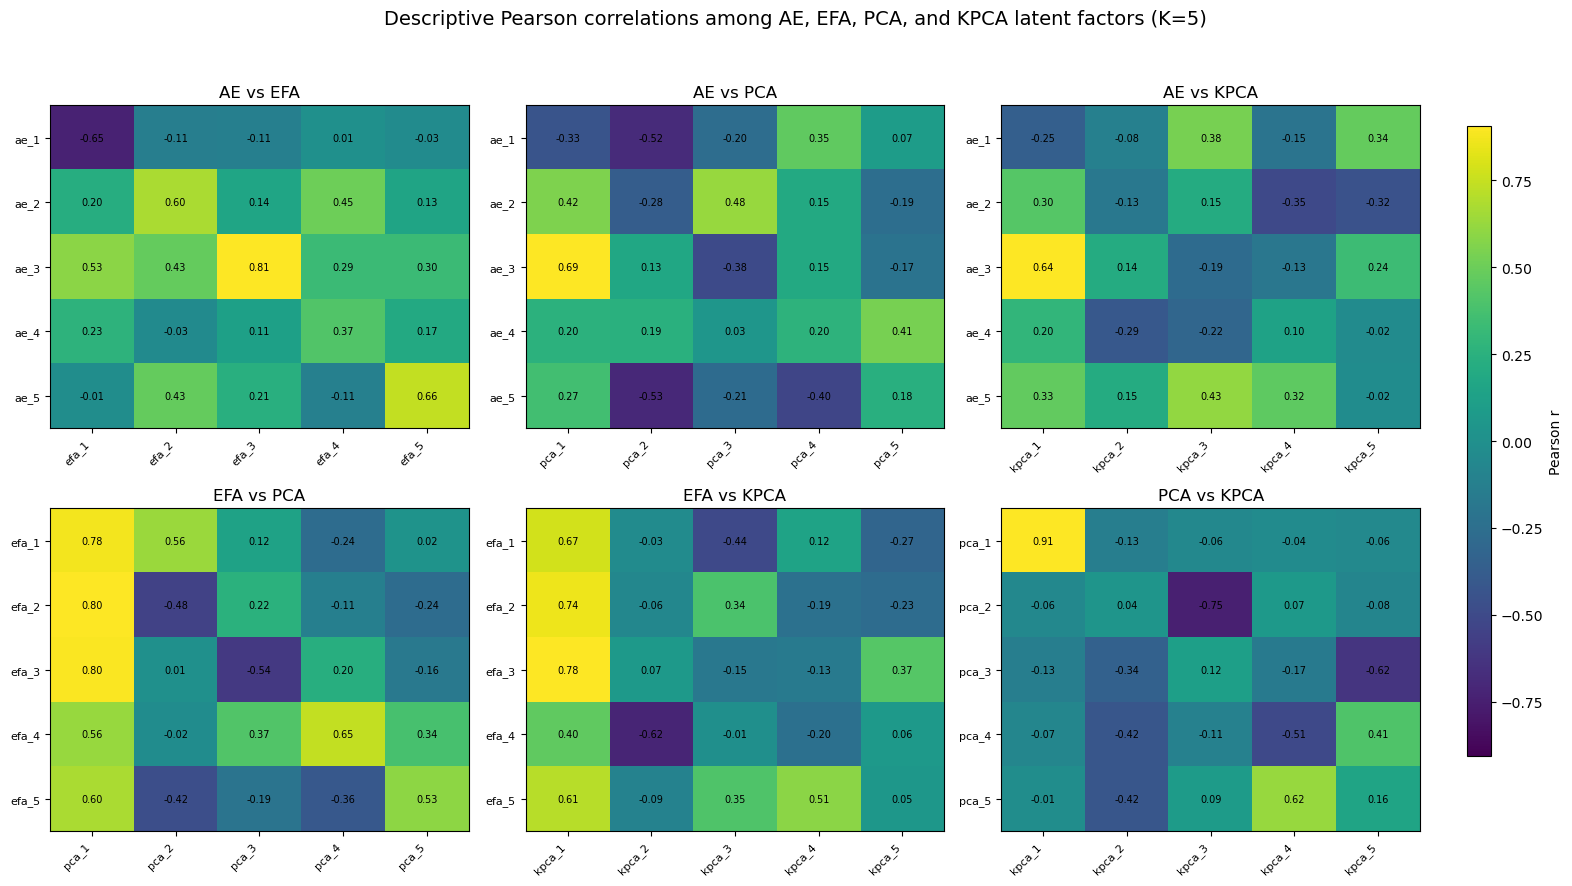

Saved combined heatmap figure to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive\all_pairwise_AE_EFA_PCA_KPCA_dim5_pearson_heatmaps_descriptive.png


In [ ]:
# ============================================================
# One combined 2 × 3 heatmap figure for all pairwise comparisons
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.reshape(-1)

for ax, (name_a, name_b) in zip(axes, comparison_pairs):
    out = corr_results[(name_a, name_b)]
    r_matrix = out["r_matrix"]

    vmax = np.nanmax(np.abs(r_matrix.values))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1

    im = ax.imshow(
        r_matrix.values,
        aspect="auto",
        vmin=-vmax,
        vmax=vmax,
    )

    ax.set_title(f"{name_a} vs {name_b}")
    ax.set_xticks(np.arange(r_matrix.shape[1]))
    ax.set_xticklabels(r_matrix.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(np.arange(r_matrix.shape[0]))
    ax.set_yticklabels(r_matrix.index, fontsize=8)

    # Descriptive plot: annotate Pearson r only, no p-value stars.
    for i in range(r_matrix.shape[0]):
        for j in range(r_matrix.shape[1]):
            r_val = r_matrix.iloc[i, j]
            if np.isfinite(r_val):
                ax.text(j, i, f"{r_val:.2f}", ha="center", va="center", fontsize=7)

# Shared colorbar
fig.subplots_adjust(right=0.90)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
fig.colorbar(im, cax=cbar_ax, label="Pearson r")

fig.suptitle(
    f"Descriptive Pearson correlations among AE, EFA, PCA, and KPCA latent factors (K={K})",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 0.90, 0.95])

combined_fig_path = results_dir / f"all_pairwise_AE_EFA_PCA_KPCA_dim{K}_pearson_heatmaps.png"
plt.savefig(combined_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved combined heatmap figure to:", combined_fig_path)


In [ ]:
# ============================================================
# Best matches for each comparison
# ============================================================

best_match_frames = []

for name_a, name_b in comparison_pairs:
    best = get_best_matches(corr_results[(name_a, name_b)], name_a, name_b)
    best.insert(0, "comparison", f"{name_a}_vs_{name_b}")
    best_match_frames.append(best)

    print(f"\nBest matches: {name_a} vs {name_b}")
    display(best)

best_matches_all = pd.concat(best_match_frames, axis=0, ignore_index=True)
best_matches_path = results_dir / f"all_pairwise_AE_EFA_PCA_KPCA_dim{K}_best_matches.csv"
best_matches_all.to_csv(best_matches_path, index=False, encoding="utf-8-sig")

print("Saved all best matches to:", best_matches_path)



Best matches: AE vs EFA


,comparison,AE_factor,EFA_factor,n,pearson_r,abs_r,p_value_unadjusted
0,AE_vs_EFA,ae_1,efa_1,9799,-0.650922,0.650922,0.000000e+00
1,AE_vs_EFA,ae_2,efa_2,9799,0.603486,0.603486,0.000000e+00
2,AE_vs_EFA,ae_3,efa_3,9799,0.806594,0.806594,0.000000e+00
3,AE_vs_EFA,ae_4,efa_4,9799,0.368424,0.368424,1.005723e-312
4,AE_vs_EFA,ae_5,efa_5,9799,0.658203,0.658203,0.000000e+00



Best matches: AE vs PCA


,comparison,AE_factor,PCA_factor,n,pearson_r,abs_r,p_value_unadjusted
0,AE_vs_PCA,ae_1,pca_2,9799,-0.520881,0.520881,0.0
1,AE_vs_PCA,ae_2,pca_3,9799,0.479604,0.479604,0.0
2,AE_vs_PCA,ae_3,pca_1,9799,0.690986,0.690986,0.0
3,AE_vs_PCA,ae_4,pca_5,9799,0.410116,0.410116,0.0
4,AE_vs_PCA,ae_5,pca_2,9799,-0.530900,0.530900,0.0



Best matches: AE vs KPCA


...


Best matches: EFA vs KPCA


,comparison,EFA_factor,KPCA_factor,n,pearson_r,abs_r,p_value_unadjusted
0,EFA_vs_KPCA,efa_1,kpca_1,9799,0.672815,0.672815,0.0
1,EFA_vs_KPCA,efa_2,kpca_1,9799,0.740549,0.740549,0.0
2,EFA_vs_KPCA,efa_3,kpca_1,9799,0.778186,0.778186,0.0
3,EFA_vs_KPCA,efa_4,kpca_2,9799,-0.619321,0.619321,0.0
4,EFA_vs_KPCA,efa_5,kpca_1,9799,0.610451,0.610451,0.0



Best matches: PCA vs KPCA


,comparison,PCA_factor,KPCA_factor,n,pearson_r,abs_r,p_value_unadjusted
0,PCA_vs_KPCA,pca_1,kpca_1,9799,0.905958,0.905958,0.0
1,PCA_vs_KPCA,pca_2,kpca_3,9799,-0.745547,0.745547,0.0
2,PCA_vs_KPCA,pca_3,kpca_5,9799,-0.622861,0.622861,0.0
3,PCA_vs_KPCA,pca_4,kpca_4,9799,-0.505762,0.505762,0.0
4,PCA_vs_KPCA,pca_5,kpca_4,9799,0.623177,0.623177,0.0


Saved all best matches to: g:\ABCD\script\trail\notebooks\temp\ae_efa_pca_kpca_factor_similarity_descriptive\all_pairwise_AE_EFA_PCA_KPCA_dim5_best_matches_descriptive.csv
